# Funções

Funções são blocos de código reutilizavéis, que podemos definir no nosso código e acessar sempre que necessário. Dessa forma, nos poupamos de repetir algumas operações repetidas vezes.

Para criar uma função usamos:

```python
def nome_da_funcao(argumento1, argumento2, ...):
    # escopo
    return resultado # opcional
```
Note que:
1. `nome_da_funcao` é definido por você,
2. `argumento1, argumento2, ...` são as entradas que a função vai receber. Você pode usar quantas quiser. Incluindo nenhuma
3. `return` é uma instrução que permite que a função *retorne* algum resultado para fora dela.

In [3]:
def faz_apresentacao(nome):
    print(f"Muito prazer, me chamo {nome}")

In [4]:
faz_apresentacao("Mozart")
faz_apresentacao("Debussy")
faz_apresentacao("Villa-Lobos")

Muito prazer, me chamo Mozart
Muito prazer, me chamo Debussy
Muito prazer, me chamo Villa-Lobos


### Exemplo: valor presente

O **valor presente** (VP) é um conceito financeiro que representa o valor atual de um montante que será recebido no futuro, descontado a uma taxa de juros específica. Essa abordagem é fundamental para a avaliação de investimentos, financiamentos e qualquer situação em que o dinheiro seja recebido ou pago em diferentes momentos.

A fórmula para calcular o valor presente é dada por:

$$
PV = \frac{FV}{(1 + r)^n}
$$

- \( PV \) = Valor Presente
- \( FV \) = Valor Futuro (o montante que você deseja trazer para o presente)
- \( r \) = Taxa de juros (ou taxa de desconto) em decimal (por exemplo, 5\% = 0,05)
- \( n \) = Número de períodos (anos, meses, etc.) até o valor futuro ser realizado

**Interpretação**

- **Desconto**: O valor presente considera o efeito do tempo sobre o dinheiro. Um montante a ser recebido no futuro vale menos hoje devido à possibilidade de ganho de juros. Quanto maior a taxa de juros ou o número de períodos, menor será o valor presente.
- **Decisões de Investimento**: O conceito de valor presente é usado para avaliar se um investimento é viável. Se o valor presente dos fluxos de caixa futuros de um investimento é maior que o custo do investimento, ele pode ser considerado atrativo.

In [5]:
def valor_presente(fv, r, n):
    """
    Calcula o valor presente (PV) a partir do valor futuro (FV), taxa de juros (r) e número de períodos (n).

    :param fv: valor futuro
    :param r: Taxa de juros (em decimal)
    :param n: Número de períodos
    :return: Valor Presente
    """
    pv = fv /(1 + r) ** n
    return pv

# Exemplo de Uso
valor_futuro = 1000 #R$1.000,00
taxa_juros = 0.05   #5%
periodos = 3        # 3 anos

resultado = valor_presente(valor_futuro, taxa_juros, periodos)
print(f"O Valor presente é: R$ {resultado}")

O Valor presente é: R$ 863.837598531476


### Argumentos variáveis

Em Python, é possível definir funções que aceitam um número variável de argumentos. Isso é útil quando não se sabe quantos argumentos serão passados para a função. Existem duas maneiras principais de fazer isso: usando `*args` e `**kwargs`.

`*args`: permite que você passe um número arbitrário de argumentos posicionais para uma função. Os argumentos são tratados como uma tupla dentro da função.

```python
def soma(*args):
    return sum(args)

resultado = soma(1, 2, 3, 4)  # Saída: 10
```

`**kwargs` permite que você passe um número arbitrário de argumentos nomeados (ou seja, argumentos com chave e valor). Os argumentos são tratados como um dicionário dentro da função.

```python
def imprime_nomes(**kwargs):
    for chave, valor in kwargs.items():
        print(f"{chave}: {valor}")

imprime_nomes(nome="Alice", idade=30)  # Saída: nome: Alice; idade: 30
```

In [6]:
def soma(*args):
    return sum(args)
print(soma(1,2))
print(soma(1,2, 3))
print(soma(100,80, 31, 42))

3
6
253


In [7]:
def imprime_nomes(**kwargs):
    for chave, valor in kwargs.items():
        print(f"{chave}: {valor}")
imprime_nomes(nome="Alice", idade=30)

nome: Alice
idade: 30


In [8]:
def calcular_total_vendas(**vendas):
    total = 0
    for produto, preco in vendas.items():
        total += preco
        print(f"Produto: {produto}, Vendas R${preco:.2f}")
    return total

#Exemplo de uso
total_vendas = calcular_total_vendas(
    produto1=199.90,
    produto2=89.90,
    produto3=249.90,
    produto4=59.99
)

print(f"Total de Vendas: R${total_vendas:.2f}")

Produto: produto1, Vendas R$199.90
Produto: produto2, Vendas R$89.90
Produto: produto3, Vendas R$249.90
Produto: produto4, Vendas R$59.99
Total de Vendas: R$599.69


## Argumentos padrões

Argumentos padrões em funções Python são valores que você pode definir como "padrões" para certos parâmetros ao criar uma função. Se o usuário da função não passar um valor específico para esse parâmetro, o valor padrão será utilizado automaticamente. No entanto, se um valor for fornecido, ele substituirá o valor padrão.

```py
def minha_funcao(arg_normal1, arg_normal2, …, arg_padrao_1=valor_padrao1, arg_padrao_2=valor_padrao2):
    ...
```

Note que devemos colocar os argumentos padrão no final da criação, para que o python saiba como lidar com argumentos posicionais.

In [9]:
def saudacao(nome="Mundo"):
    print(f"Olá, {nome}!")

saudacao()

saudacao("Ana")

Olá, Mundo!
Olá, Ana!


### Pandas e método apply

O método `.apply()` no pandas permite aplicar uma função a cada elemento de uma coluna ou linha de um DataFrame. É útil quando você quer realizar operações mais complexas em cada valor de uma série ou em cada linha/coluna do DataFrame.

Pense no `.apply()` como uma forma de pedir ao pandas para "passar por cada valor" e fazer algo com ele. Por exemplo, se você quiser dobrar todos os números em uma coluna, você pode usar o `.apply()` para aplicar uma função que faz essa multiplicação.

In [10]:
import pandas as pd

df1 = pd.DataFrame({
    "nome":["Pedro", "Paula", "Severino"],
    "idade":[29, 12, 61]
})

In [11]:
display(df1)

,nome,idade
0,Pedro,29
1,Paula,12
2,Severino,61


In [12]:
def extrai_faixa_etaria(idade):
    if idade <= 18:
        faixa_etaria = "jovem"
    elif 18 < idade < 60:
        faixa_etaria = "adulto"
    else: 
        faixa_etaria = "idoso"
    return faixa_etaria

df1["faixa_etaria"] = df1["idade"].apply(extrai_faixa_etaria)

display(df1)


,nome,idade,faixa_etaria
0,Pedro,29,adulto
1,Paula,12,jovem
2,Severino,61,idoso


O `axis` ajuda a decidir se você quer aplicar uma função em cada linha ou em cada coluna. Pense nele como a "direção" em que a função vai trabalhar.

1. `axis=0` (ou seja, o valor padrão) aplica a função ao longo das colunas, ou seja, para cada valor em uma coluna de cada vez.
2. `axis=1` aplica a função ao longo das linhas, ou seja, para cada valor em uma linha de cada vez.

In [13]:
df2 = pd.DataFrame({
    "nome":["Ana", "Josefá", "Gisele"],
    "renda": [4000, 6000, 20000],
    "score": [800, 600, 900]
})

display(df2)

,nome,renda,score
0,Ana,4000,800
1,Josefá,6000,600
2,Gisele,20000,900


In [14]:
def extrai_clasificacao_risco(linha):
    if linha["renda"] > 10000 and linha["score"] > 700:
        classificacao = "baixo risco"
    elif linha["renda"] > 5000 and linha ["score"] > 600:
        classificacao = "médio risco"
    else:
        classificacao = "alto risco"
    return classificacao

df2["Classificacao"] = df2.apply(extrai_clasificacao_risco, axis = 1) # axis= 1 para olhar para a linha e nao coluna 

display(df2)

,nome,renda,score,Classificacao
0,Ana,4000,800,alto risco
1,Josefá,6000,600,alto risco
2,Gisele,20000,900,baixo risco


## Funções lambda

As funções lambda em Python são uma forma concisa de criar funções anônimas (sem nome) em uma única linha de código. Elas são particularmente úteis quando você precisa de uma função simples para ser utilizada temporariamente, como em operações de mapeamento ou filtragem.
Sua sintaxe básica é:

```python
lambda argumentos: expressão
```
Em que:
- `lambda`: Palavra-chave que indica que estamos criando uma função anônima.
- `argumentos`: Uma lista de parâmetros (podem ser múltiplos ou nenhum).
- `expressão`: Uma única expressão que será avaliada e retornada. Ela é o `return` da função `def`.

In [15]:
soma = lambda x, y: x + y
print(soma(3, 5))
print(soma(1, 2))

print("=" * 30)

#equilavente a
def soma(x, y):
    return x + y
print(soma(3, 5))
print(soma(1, 2))

8
3
8
3


### Vantagens e Desvantagens

#### Vantagens:
- Sintaxe compacta e legível para funções simples.
- Útil em contextos onde funções pequenas são necessárias temporariamente.

#### Desvantagens:
- Limitadas a uma única expressão, o que pode reduzir a clareza em funções mais complexas.
- Não é possível usar múltiplas instruções ou anotações de tipo.

Exemplo: considere que você tem um dataframe como o apresentado abaixo, como calcular o preço com desconto de cada item?

In [16]:
import pandas as pd

dados = {
    'Produto': ['Produto A', 'Produto B', 'Produto C'],
    'Preco_Original': [100.00, 200.00, 300.00],
    'Desconto': [10, 20, 15]
}

df3 = pd.DataFrame(dados)
display(df3)

,Produto,Preco_Original,Desconto
0,Produto A,100.0,10
1,Produto B,200.0,20
2,Produto C,300.0,15


In [17]:
#solução def
def calcula_preco_com_desconto(linha):
    return linha['Preco_Original'] * (1 - linha['Desconto'] / 100)
df3['Preco_Descontado'] = df3.apply(calcula_preco_com_desconto, axis=1)

display(df3)

,Produto,Preco_Original,Desconto,Preco_Descontado
0,Produto A,100.0,10,90.0
1,Produto B,200.0,20,160.0
2,Produto C,300.0,15,255.0


In [18]:
#solução lambda

df3['Preco_Descontado_lambda'] = df3.apply(lambda l: l['Preco_Original'] * (1 - l['Desconto'] / 100), axis=1)

display(df3)

,Produto,Preco_Original,Desconto,Preco_Descontado,Preco_Descontado_lambda
0,Produto A,100.0,10,90.0,90.0
1,Produto B,200.0,20,160.0,160.0
2,Produto C,300.0,15,255.0,255.0


## Exemplo revisitado

**Regressão linear multivariável**: problema de predição da capacidade pulmonar (`fev`) através de informações de altura (`height`), sexo (`sex`) e idade (`age`).

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [20]:
df = pd.read_csv("C:/Users/João Luís/Desktop/eba-analista/data/df_fev2.csv")
df.head()

,Unnamed: 0,age,fev,height,sex,smoke
0,0,9,1.953,68.0,masculino,sim
1,1,10,2.236,66.0,feminino,sim
2,3,13,2.216,68.0,feminino,sim
3,4,12,1.953,66.0,masculino,sim
4,5,10,2.198,62.0,feminino,sim


In [21]:
df["smoke"].value_counts()

smoke
nao    584
sim     70
Name: count, dtype: int64

In [22]:
df["sex"].value_counts()

sex
masculino    335
feminino     319
Name: count, dtype: int64

In [23]:
df.isna().mean()

Unnamed: 0    0.0
age           0.0
fev           0.0
height        0.0
sex           0.0
smoke         0.0
dtype: float64

In [24]:
df_limpo = df.drop(columns=["Unnamed: 0"])

df_limpo["smoke"] = df_limpo["smoke"].apply(lambda x: 1 if x== "sim" else 0)

df_limpo["sex"] = df_limpo["sex"].apply(lambda x: 1 if x == "masculino" else 0)

df_limpo["log_fev"] = np.log(df_limpo["fev"])

df_limpo.head()

,age,fev,height,sex,smoke,log_fev
0,9,1.953,68.0,1,1,0.669367
1,10,2.236,66.0,0,1,0.804689
2,13,2.216,68.0,0,1,0.795704
3,12,1.953,66.0,1,1,0.669367
4,10,2.198,62.0,0,1,0.787548


In [25]:
def ajuesta_modelo(dados, formula):
    
    mod = smf.ols(formula=formula, data=dados)
    res = mod.fit()

    fig, ax = plt.subplots(figsize=(5,5))

    sns.residplot(x=res.fittedvalues, y=res.resid, lowess=True, ax=ax)
    ax.set_title(formula)
    ax.set(xlabel='Fitted', ylabel='Residuals')

    return res

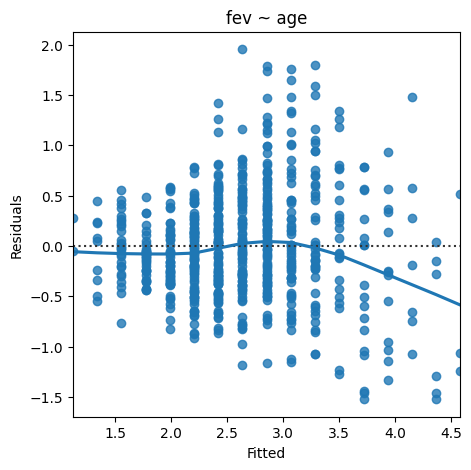

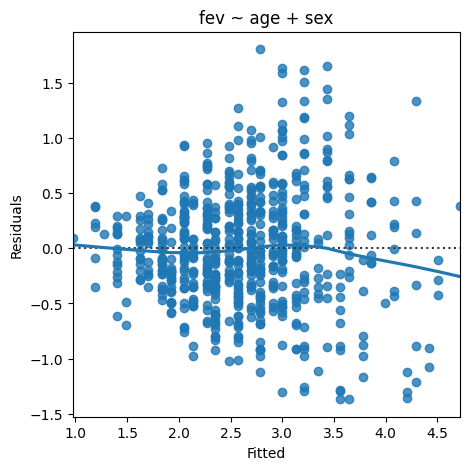

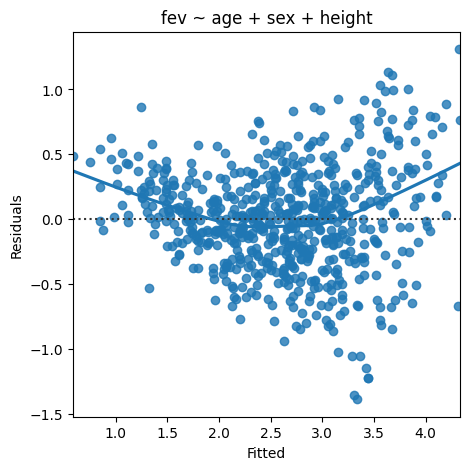

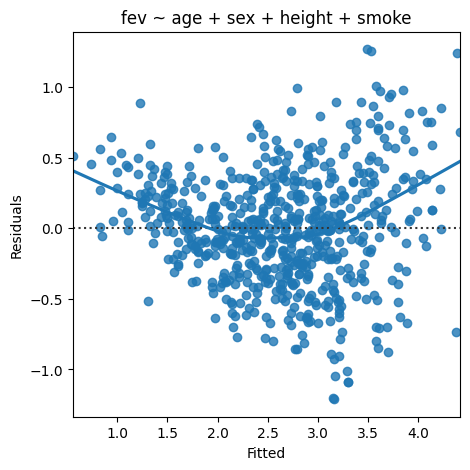

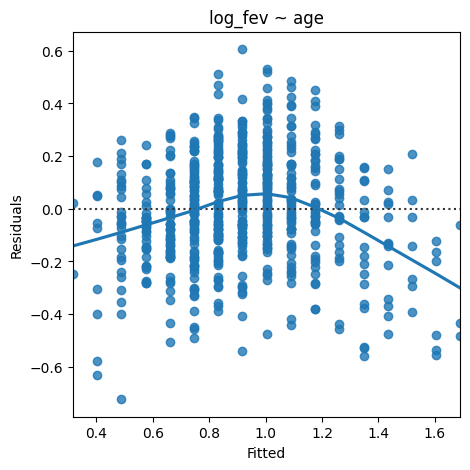

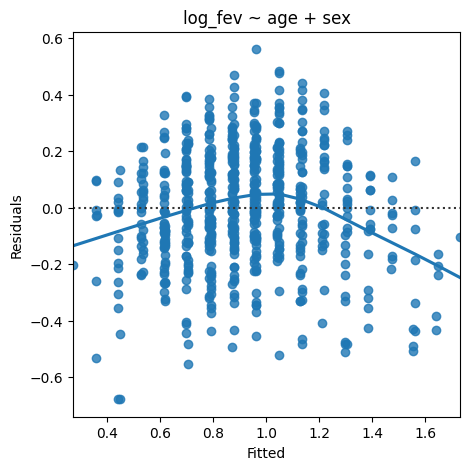

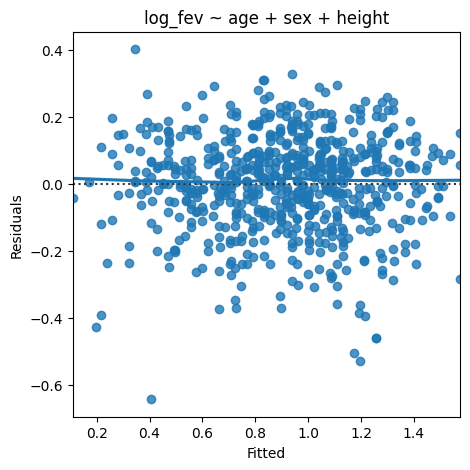

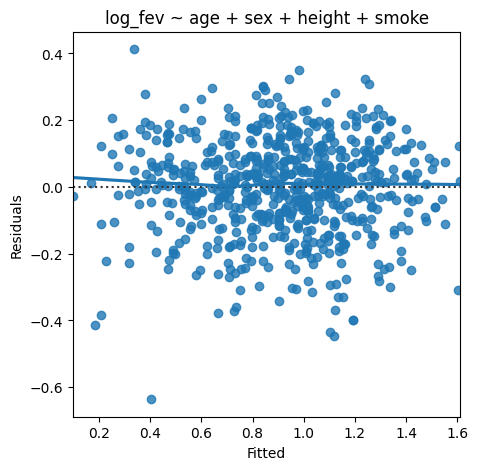

In [26]:
formulas = [
    "fev ~ age",
    "fev ~ age + sex",
    "fev ~ age + sex + height",
    "fev ~ age + sex + height + smoke",
    "log_fev ~ age",
    "log_fev ~ age + sex",
    "log_fev ~ age + sex + height",
    "log_fev ~ age + sex + height + smoke",
]

modelos = []

for formula in formulas:
    res = ajuesta_modelo(df_limpo, formula)
    modelos.append(res)

In [27]:
modelos[0].rsquared

np.float64(0.5689801464257156)

In [28]:
for i, modelo in enumerate(modelos):
    print("modelo", formulas[i], "R2", modelo.rsquared)

modelo fev ~ age R2 0.5689801464257156
modelo fev ~ age + sex R2 0.6007753241541229
modelo fev ~ age + sex + height R2 0.7742976904396359
modelo fev ~ age + sex + height + smoke R2 0.7780945693372415
modelo log_fev ~ age R2 0.5885662719664103
modelo log_fev ~ age + sex R2 0.6084183841603742
modelo log_fev ~ age + sex + height R2 0.803166622965996
modelo log_fev ~ age + sex + height + smoke R2 0.8082367768739668


In [30]:
for modelo, formula in zip(modelos, formulas):
    print("modelo", formula, "R2", modelo.rsquared)

modelo fev ~ age R2 0.5689801464257156
modelo fev ~ age + sex R2 0.6007753241541229
modelo fev ~ age + sex + height R2 0.7742976904396359
modelo fev ~ age + sex + height + smoke R2 0.7780945693372415
modelo log_fev ~ age R2 0.5885662719664103
modelo log_fev ~ age + sex R2 0.6084183841603742
modelo log_fev ~ age + sex + height R2 0.803166622965996
modelo log_fev ~ age + sex + height + smoke R2 0.8082367768739668
